# §5 — VLM qualitative evaluation

Loads the best VLM checkpoint from the freeze-comparison sweep (default: `vlm_all_patches_image_bidir_B`), runs greedy generation on a 500-example CLEVR-val pool, and dumps 10 examples (~half correct, ~half wrong) with image + question + gold + prediction. Used to characterize whether failure modes are *encoder* (image misunderstood) or *decoder* (question misinterpreted).

**Prereqs:** A trained `projector.pt` from one of the §5 runs (e.g. produced by `freeze_compare.ipynb`), and the §3 CLIP-pretrained ViT at `runs/clip_eurosat/best.pt`.

**Output:** `runs/vlm_qualitative/{examples.jsonl, examples.md, images/, summary.json}` — synced to Drive.

## 1. Install dependencies

In [1]:
%%capture
!pip -q install -U transformers datasets "sentence-transformers<4.0" accelerate tqdm matplotlib pyyaml einops
!pip -q install --force-reinstall --no-deps --no-cache-dir pillow==11.3.0

## 2. Mount Drive and set up the repo path

In [2]:
import os, sys
from pathlib import Path

USE_DRIVE = True
DRIVE_REPO_ROOT = Path('/content/drive/MyDrive/caltech/junior/hw3/')  # edit if needed

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    REPO_ROOT = DRIVE_REPO_ROOT
else:
    REPO_ROOT = Path('/content/hw3')

assert REPO_ROOT.exists(), f'Repo root does not exist: {REPO_ROOT}'
sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)
print('cwd =', os.getcwd())

Mounted at /content/drive
cwd = /content/drive/MyDrive/caltech/junior/hw3


In [3]:
import torch, torchvision

print('torch:', torch.__version__, '| cuda:', torch.cuda.is_available())
torchvision.ops.nms(torch.zeros(0, 4), torch.zeros(0), 0.5)

torch: 2.10.0+cu128 | cuda: True


tensor([], dtype=torch.int64)

## 3. Pick the best checkpoint to evaluate

Defaults to **all_patches + image_bidir + freeze_config B** (typically the Pareto winner from the §5 sweep). Change `RUN_NAME` to any of your other runs.

In [4]:
RUN_NAME = 'vlm_all_patches_image_bidir_B'   # edit if your best was a different config

CHECKPOINT = REPO_ROOT / 'runs' / RUN_NAME / 'projector.pt'
PRETRAINED_VIT = REPO_ROOT / 'runs' / 'clip_eurosat' / 'best.pt'
CLEVR_ROOT = REPO_ROOT / 'data' / 'clevr_mini'
OUT_DIR_DRIVE = REPO_ROOT / 'runs' / 'vlm_qualitative'
OUT_DIR_LOCAL = Path('/content/runs/vlm_qualitative')

for p in (CHECKPOINT, PRETRAINED_VIT, CLEVR_ROOT):
    assert p.exists(), f'missing: {p}'
OUT_DIR_LOCAL.mkdir(parents=True, exist_ok=True)
OUT_DIR_DRIVE.mkdir(parents=True, exist_ok=True)
print(f'checkpoint = {CHECKPOINT}')
print(f'pretrained ViT = {PRETRAINED_VIT}')

checkpoint = /content/drive/MyDrive/caltech/junior/hw3/runs/vlm_all_patches_image_bidir_B/projector.pt
pretrained ViT = /content/drive/MyDrive/caltech/junior/hw3/runs/clip_eurosat/best.pt


## 4. Run the qualitative eval

Uses the Python entry point directly so the model stays in memory for later cells. Writes outputs locally first, then syncs to Drive.

In [5]:
import argparse
from scripts.eval_vlm import (
    build_model_for_eval, generate_all, sample_balanced, write_outputs,
)
from vlm.data import CLEVRMiniDataset
from vlm.eval import batch_clevr_accuracy

MAX_EVAL = 500
NUM_EXAMPLES = 10
MAX_NEW_TOKENS = 8

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ckpt = torch.load(CHECKPOINT, map_location='cpu', weights_only=False)
cfg = ckpt['config']
print(f"checkpoint config: injection={cfg['injection']}  "
      f"mask_mode={cfg.get('mask_mode')}  freeze={cfg.get('freeze_config')}")

model, _ = build_model_for_eval(ckpt, PRETRAINED_VIT, attn_impl='sdpa')
model.to(device).eval()

val_ds = CLEVRMiniDataset(split='val', root=str(CLEVR_ROOT), img_size=cfg['vit']['img_size'])
results = generate_all(model, val_ds, injection=cfg['injection'], device=device,
                       max_eval=MAX_EVAL, max_new_tokens=MAX_NEW_TOKENS)

overall = batch_clevr_accuracy(
    [r['prediction'] for r in results],
    [r['gold'] for r in results],
    [r['q_type'] for r in results],
)
n_correct = sum(1 for r in results if r['correct'])
print(f"\nscored {len(results)} examples: {n_correct}/{len(results)} correct "
      f"({n_correct / len(results):.2%})")
for k, v in overall.items():
    if k != 'overall':
        print(f'  {k:>16}: {v:.4f}')

sampled = sample_balanced(results, NUM_EXAMPLES, seed=0)
write_outputs(sampled, OUT_DIR_LOCAL, CLEVR_ROOT, save_images=True)

# Sync local outputs to Drive (single-shot)
import shutil
(OUT_DIR_DRIVE / 'images').mkdir(parents=True, exist_ok=True)
for f in (OUT_DIR_LOCAL / 'images').glob('*'):
    shutil.copy2(f, OUT_DIR_DRIVE / 'images' / f.name)
for fname in ('examples.jsonl', 'examples.md'):
    shutil.copy2(OUT_DIR_LOCAL / fname, OUT_DIR_DRIVE / fname)

import json
with open(OUT_DIR_DRIVE / 'summary.json', 'w') as f:
    json.dump({
        'checkpoint': str(CHECKPOINT),
        'split': 'val',
        'max_eval': MAX_EVAL,
        'num_correct': n_correct,
        'overall_metrics': overall,
        'config': cfg,
    }, f, indent=2)
print(f'\nsynced -> {OUT_DIR_DRIVE}')

checkpoint config: injection=all_patches  mask_mode=None  freeze=None


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/724M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

loaded legacy projector-only checkpoint


generate:   0%|          | 0/500 [00:00<?, ?it/s]


scored 500 examples: 0/500 correct (0.00%)
           spatial: 0.0000
      compare_attr: 0.0000
             count: 0.0000
        query_attr: 0.0000
             exist: 0.0000
wrote /content/runs/vlm_qualitative/examples.jsonl
wrote /content/runs/vlm_qualitative/examples.md

synced -> /content/drive/MyDrive/caltech/junior/hw3/runs/vlm_qualitative


## 5. Render the 10 examples inline

Image + Question + Gold + Prediction + correct/incorrect, in a notebook-friendly grid.

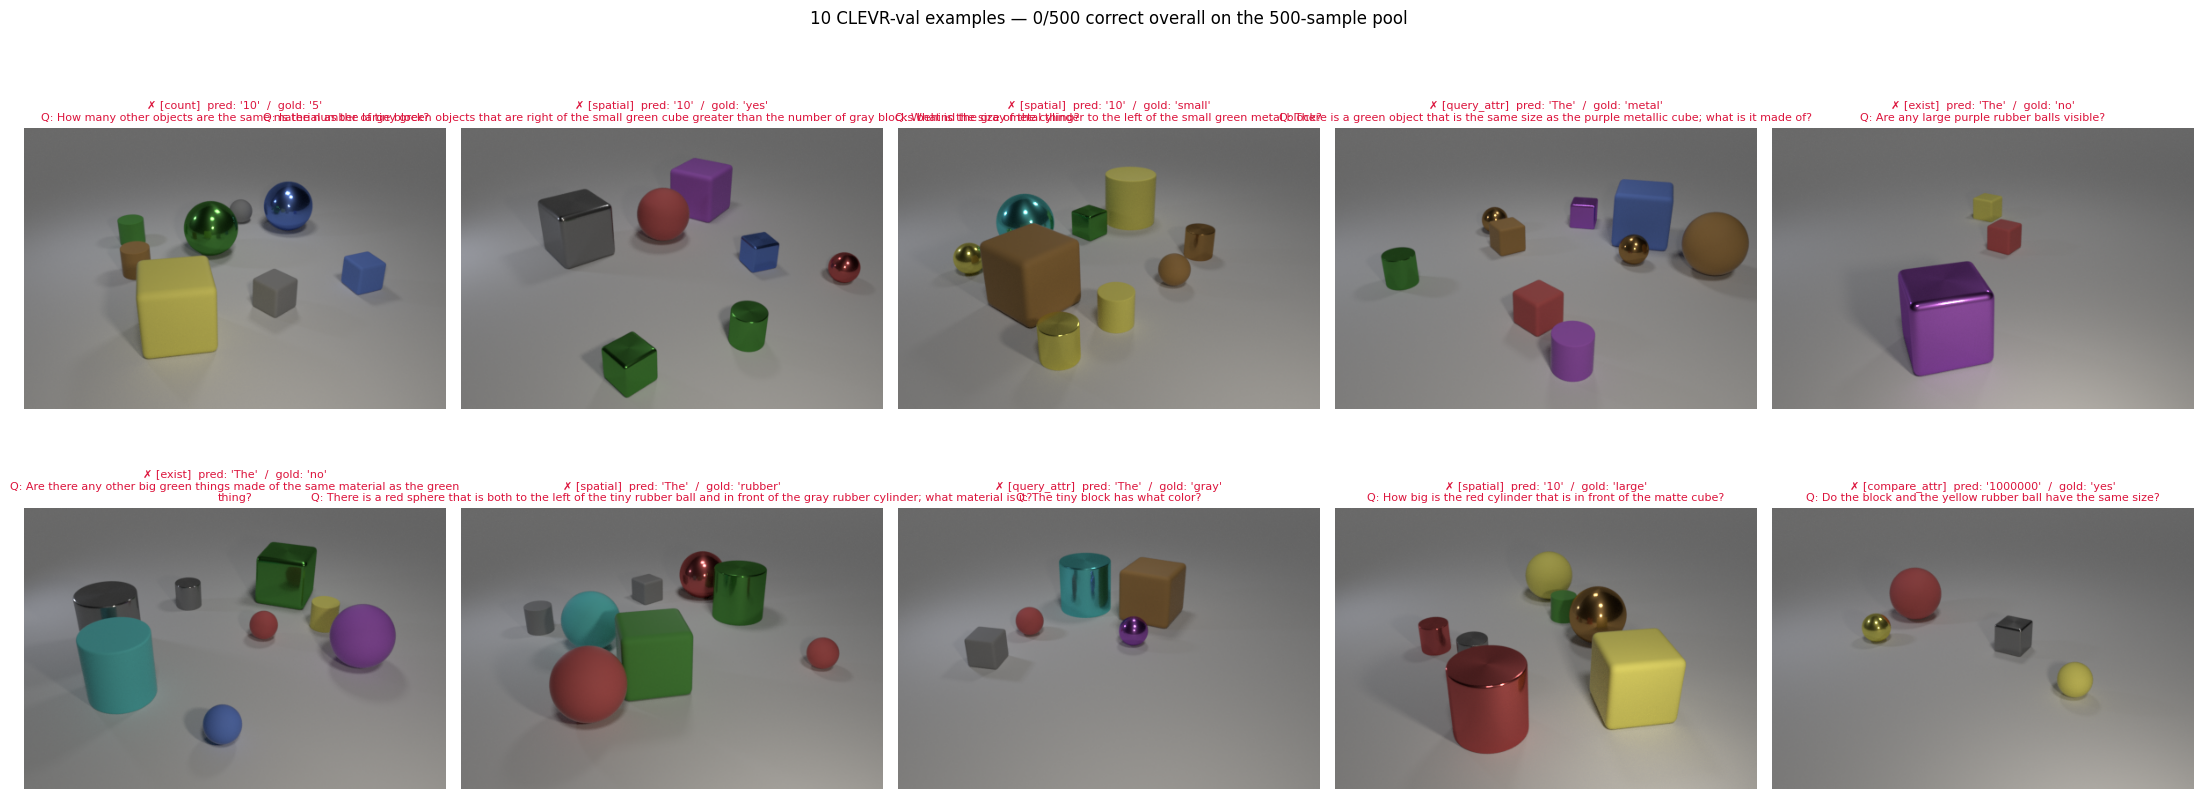

saved /content/drive/MyDrive/caltech/junior/hw3/runs/vlm_qualitative/qualitative_grid.png


In [6]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
for ax, e in zip(axes.flat, sampled):
    img = Image.open(CLEVR_ROOT / 'images' / e['image_file']).convert('RGB')
    ax.imshow(img)
    ax.axis('off')
    status = '\u2713' if e['correct'] else '\u2717'
    color = 'darkgreen' if e['correct'] else 'crimson'
    title = (
        f"{status} [{e['q_type']}]  pred: {e['prediction']!r}  /  gold: {e['gold']!r}\n"
        f"Q: {e['question']}"
    )
    # Wrap long question text manually.
    ax.set_title(title, fontsize=8, color=color, wrap=True)

fig.suptitle(
    f'10 CLEVR-val examples — {n_correct}/{len(results)} correct overall on the {MAX_EVAL}-sample pool',
    fontsize=12,
)
fig.tight_layout()

local_fig = OUT_DIR_LOCAL / 'qualitative_grid.png'
fig.savefig(local_fig, dpi=130, bbox_inches='tight')
shutil.copy2(local_fig, OUT_DIR_DRIVE / 'qualitative_grid.png')
plt.show()
print(f'saved {OUT_DIR_DRIVE / "qualitative_grid.png"}')

## 6. Per-example failure-mode table

Prints a table with one row per dumped example, including the columns the deliverable asks for: image, question, gold, prediction, status. Use this when annotating each *incorrect* row with your encoder-vs-decoder hypothesis in §7.

In [7]:
from IPython.display import Markdown, display

lines = [
    '| # | status | q_type | image | question | gold | pred |',
    '|---|--------|--------|-------|----------|------|------|',
]
for i, e in enumerate(sampled):
    status = '\u2713' if e['correct'] else '\u2717'
    lines.append(
        f"| {i+1} | {status} | {e['q_type']} | {e['image_file']} | "
        f"{e['question']} | {e['gold']} | {e['prediction']} |"
    )
display(Markdown('\n'.join(lines)))

| # | status | q_type | image | question | gold | pred |
|---|--------|--------|-------|----------|------|------|
| 1 | ✗ | count | CLEVR_val_007694.png | How many other objects are the same material as the large block? | 5 | 10 |
| 2 | ✗ | spatial | CLEVR_val_013328.png | Is the number of tiny green objects that are right of the small green cube greater than the number of gray blocks behind the gray metal thing? | yes | 10 |
| 3 | ✗ | spatial | CLEVR_val_014105.png | What is the size of the cylinder to the left of the small green metal block? | small | 10 |
| 4 | ✗ | query_attr | CLEVR_val_000563.png | There is a green object that is the same size as the purple metallic cube; what is it made of? | metal | The |
| 5 | ✗ | exist | CLEVR_val_005997.png | Are any large purple rubber balls visible? | no | The |
| 6 | ✗ | exist | CLEVR_val_007938.png | Are there any other big green things made of the same material as the green thing? | no | The |
| 7 | ✗ | spatial | CLEVR_val_011884.png | There is a red sphere that is both to the left of the tiny rubber ball and in front of the gray rubber cylinder; what material is it? | rubber | The |
| 8 | ✗ | query_attr | CLEVR_val_014930.png | The tiny block has what color? | gray | The |
| 9 | ✗ | spatial | CLEVR_val_006556.png | How big is the red cylinder that is in front of the matte cube? | large | 10 |
| 10 | ✗ | compare_attr | CLEVR_val_004180.png | Do the block and the yellow rubber ball have the same size? | yes | 1000000 |

## 7. Writeup notes (4–5 sentences)

After inspecting the 10 examples above, fill in the discussion. Things to cover:

- **Encoder vs decoder failure-mode hypothesis.** For each incorrect example, annotate it with one of:
  - **Encoder failure** — the model named an object/attribute that isn't in the image, miscounted, or otherwise produced an answer that's *internally consistent text* but wrong about pixels (e.g. "yes" when there's no cylinder; "3" when there are 2). Suggests the projected visual tokens don't carry enough info about that object/attribute.
  - **Decoder failure** — the answer is wrong in a way that suggests the question wasn't parsed correctly (returned an attribute when asked for a count; answered yes/no when asked "what color"; ignored a clause like "to the left of the red sphere"). Suggests SmolLM2 didn't bind the visual evidence to the right question slot.
  - **Ambiguous / both** — happens often; mention this honestly.

- **Pattern.** Comment on which mode dominates in your 5 wrong cases. With config-A or short training, decoder failures (format/parse) usually dominate; with longer LoRA training the residual errors lean encoder-side (the 64×64 ViT genuinely loses small-object detail).

- **Designing a discriminating experiment.** Two clean isolations:
  1. **Encoder probe (image side).** Feed the same image to the *frozen ViT* and ask it to do a simple classification or attribute-prediction task with a fresh linear head (e.g. "is there a cyan object in this image?", "how many small cubes?"). If the ViT can be linearly read for the property, but the VLM still gets the question wrong, the bottleneck is downstream (projector / decoder grounding). If even the linear probe fails, the bottleneck is the encoder itself.
  2. **Decoder probe (text side).** Pass an *oracle scene description* in plain text to SmolLM2 (no image, no projector) and ask the same CLEVR question: e.g. "There are 3 red cubes and 1 blue cylinder. How many cubes?". If the decoder answers the textual version correctly but fails when fed image embeddings, the bottleneck is the visual→text bridge (projector / injection). If it fails on the text version too, the decoder doesn't know how to follow the CLEVR question format and needs more instruction-tuning.

  Run both probes on the 5 wrong cases and bucket them: linear-probe-OK + text-probe-OK → projector / fusion bug; linear-probe-FAIL → encoder; text-probe-FAIL → decoder.

Optional: tie to the §5 freeze comparison — if config B (LoRA) reduced decoder-side errors more than encoder-side ones, that's evidence the projector + decoder fusion was the dominant bottleneck under A.